# 04 — ProtoNet Training v2 (Improved)

Improved version: added augmentation, early stopping, learning rate scheduling, and advanced training techniques. K-shot=30, N-way=2, 500 episodes.

> **Note:** Data and model paths use relative references. Ensure the `data/` and `models/` directories are set up according to `README.md`.

In [5]:
OUTPUT_BENIGN_DIR = "../data/train/benign"
OUTPUT_MALIGNANT_DIR = "../data/train/malignant"

Số ảnh trong train_dataset: 443
Số ảnh trong test_dataset: 191
Episode 10/500, Loss: 0.5434, Train Acc: 0.7167, F1: 0.7183, Precision: 0.7236, Recall: 0.7167
Train Confusion Matrix:
[[18  7]
 [10 25]]
Val Acc: 0.7633, Val F1: 0.7610, Val Precision: 0.7757, Val Recall: 0.7633
Val Confusion Matrix:
[[23  6]
 [ 7 22]]
=== Lưu mô hình tốt nhất tại episode 10 ===
Val Acc: 0.7633, Val F1: 0.7610, Val Precision: 0.7757, Val Recall: 0.7633
Val Confusion Matrix:
[[23  6]
 [ 7 22]]
Episode 20/500, Loss: 0.4799, Train Acc: 0.7500, F1: 0.7485, Precision: 0.7680, Recall: 0.7500
Train Confusion Matrix:
[[24  4]
 [11 21]]
Val Acc: 0.8550, Val F1: 0.8551, Val Precision: 0.8634, Val Recall: 0.8550
Val Confusion Matrix:
[[26  3]
 [ 5 25]]
=== Lưu mô hình tốt nhất tại episode 20 ===
Val Acc: 0.8550, Val F1: 0.8551, Val Precision: 0.8634, Val Recall: 0.8550
Val Confusion Matrix:
[[26  3]
 [ 5 25]]
Episode 30/500, Loss: 0.3399, Train Acc: 0.8500, F1: 0.8504, Precision: 0.8512, Recall: 0.8500
Train Confusio

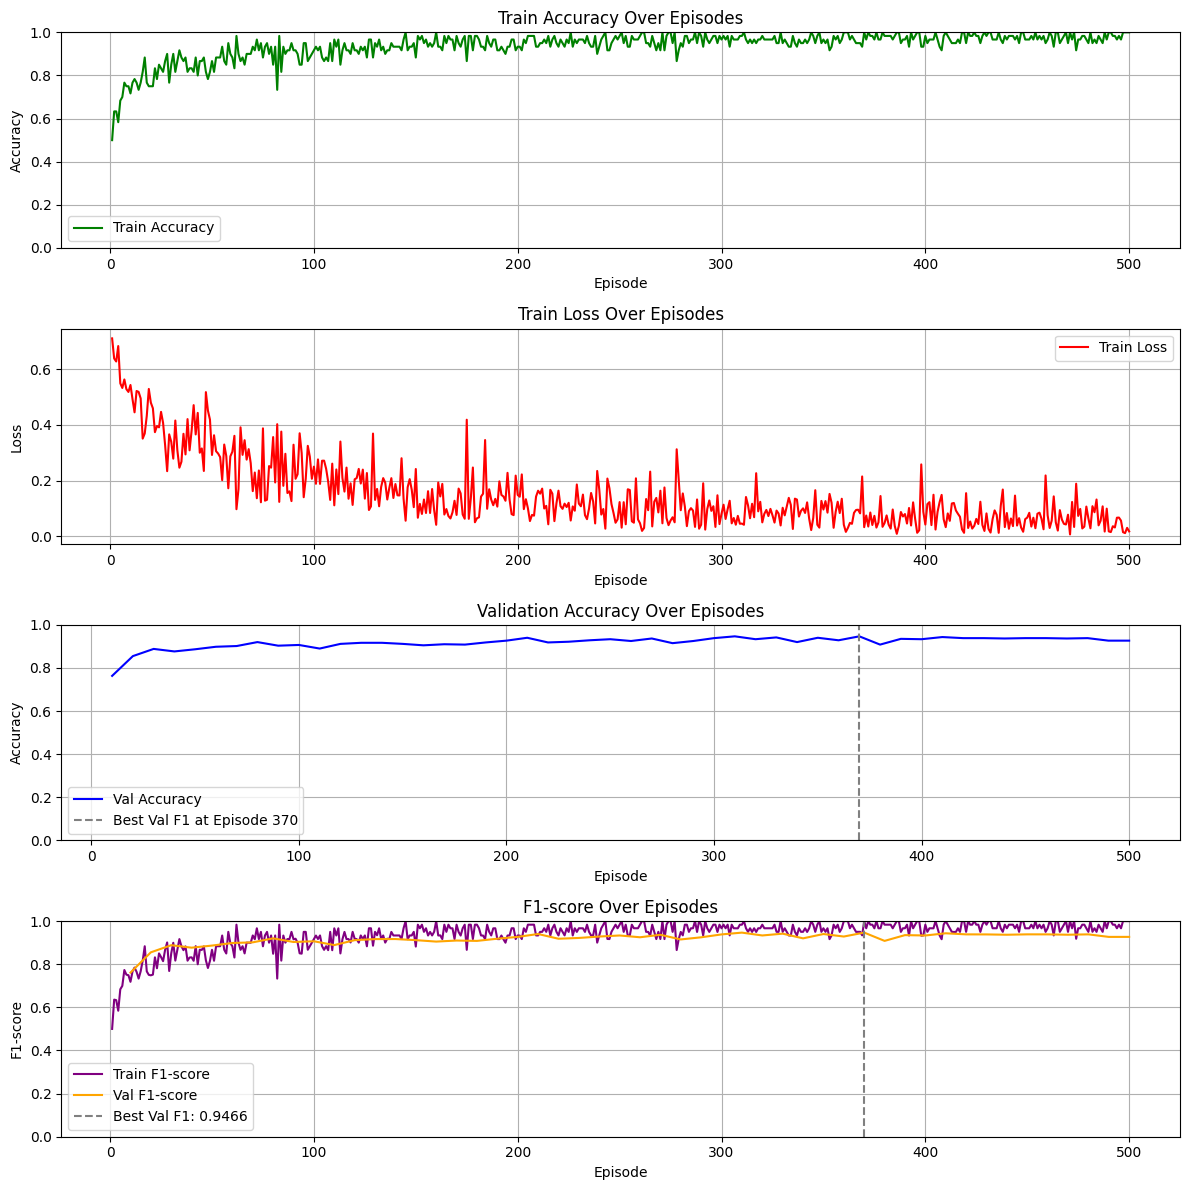

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

# Định nghĩa các tham số
OUTPUT_BENIGN_DIR = "../data/train/benign"
OUTPUT_MALIGNANT_DIR = "../data/train/malignant"
K_SHOT = 30  # Số mẫu mỗi lớp trong tập hỗ trợ
N_WAY = 2    # Số lớp (benign, malignant)
NUM_EPISODES = 500  # Tăng số episode để huấn luyện
BATCH_SIZE = 6
LEARNING_RATE = 5e-5
TEST_SIZE = 0.3  # 30% dữ liệu cho tập test
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform cho dữ liệu với data augmentation tăng cường
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomCrop(224, padding=8),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transform cho validation/test (không augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset tùy chỉnh
class LiverTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Hàm tạo episode cho few-shot learning với replace cho query
def create_episode(dataset, k_shot, n_way, train_indices):
    benign_indices = [i for i in range(len(dataset.labels)) if dataset.labels[i] == 0]
    malignant_indices = [i for i in range(len(dataset.labels)) if dataset.labels[i] == 1]
    if len(benign_indices) < k_shot or len(malignant_indices) < k_shot:
        raise ValueError(f"Không đủ ảnh. Cần ít nhất {k_shot} ảnh mỗi lớp.")
    np.random.seed(None)
    support_benign = np.random.choice(benign_indices, k_shot, replace=False)
    support_malignant = np.random.choice(malignant_indices, k_shot, replace=False)
    support_indices = list(support_benign) + list(support_malignant)
    query_indices = [i for i in range(len(dataset.labels)) if i not in support_indices]
    required_query = k_shot * n_way
    if len(query_indices) < required_query:
        print(f"Cảnh báo: Số query thiếu ({len(query_indices)} < {required_query}), sử dụng replace=True.")
        query_indices = np.random.choice(range(len(dataset.labels)), required_query, replace=True)
    else:
        query_indices = np.random.choice(query_indices, required_query, replace=False)
    support_images = torch.stack([dataset[i][0] for i in support_indices])
    support_labels = torch.tensor([dataset[i][1] for i in support_indices])
    query_images = torch.stack([dataset[i][0] for i in query_indices])
    query_labels = torch.tensor([dataset[i][1] for i in query_indices])
    return support_images, support_labels, query_images, query_labels

# Định nghĩa Prototypical Network
class ProtoNet(nn.Module):
    def __init__(self, backbone):
        super(ProtoNet, self).__init__()
        self.backbone = backbone
        self.backbone.fc = nn.Identity()

    def forward(self, support_images, support_labels, query_images):
        support_features = self.backbone(support_images)
        query_features = self.backbone(query_images)
        prototypes = []
        for c in range(N_WAY):
            mask = (support_labels == c)
            prototype = support_features[mask].mean(dim=0)
            prototypes.append(prototype)
        prototypes = torch.stack(prototypes)
        dists = torch.cdist(query_features, prototypes)
        return -dists

# Load dataset
benign_images = [os.path.join(OUTPUT_BENIGN_DIR, img) for img in os.listdir(OUTPUT_BENIGN_DIR) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]
malignant_images = [os.path.join(OUTPUT_MALIGNANT_DIR, img) for img in os.listdir(OUTPUT_MALIGNANT_DIR) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]
all_images = benign_images + malignant_images
all_labels = [0] * len(benign_images) + [1] * len(malignant_images)

# Kiểm tra số lượng ảnh hợp lệ
if len(all_images) == 0:
    raise ValueError("Không tìm thấy ảnh trong _benign hoặc _malignant.")
if len(benign_images) < K_SHOT or len(malignant_images) < K_SHOT:
    raise ValueError(f"Không đủ ảnh. Cần ít nhất {K_SHOT} ảnh mỗi lớp trong dữ liệu gốc.")

# Tách tập train và test
train_indices, test_indices = train_test_split(range(len(all_images)), test_size=TEST_SIZE, stratify=all_labels, random_state=42)
train_dataset = LiverTumorDataset([all_images[i] for i in train_indices], [all_labels[i] for i in train_indices], transform)
test_dataset = LiverTumorDataset([all_images[i] for i in test_indices], [all_labels[i] for i in test_indices], val_transform)

# In số lượng ảnh
print(f"Số ảnh trong train_dataset: {len(train_dataset)}")
print(f"Số ảnh trong test_dataset: {len(test_dataset)}")

# Load ResNet34 pre-trained
model = ProtoNet(models.resnet34(weights=models.ResNet34_Weights.DEFAULT))
model = model.to(DEVICE)

# Loss và optimizer với weight decay
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
scaler = torch.amp.GradScaler('cuda')

# Biến để theo dõi mô hình tốt nhất
best_val_f1 = 0.0
best_episode = 0
best_model_path = 'best_protonet_liver_tumor_resnet34.pth'
best_val_acc = 0.0
best_val_precision = 0.0
best_val_recall = 0.0
best_val_cm = np.zeros((N_WAY, N_WAY), dtype=int)

# Huấn luyện
model.train()
train_acc_history = []
train_loss_history = []
val_acc_history = []
train_f1_history = []
val_f1_history = []

for episode in range(NUM_EPISODES):
    support_images, support_labels, query_images, query_labels = create_episode(train_dataset, K_SHOT, N_WAY, range(len(train_dataset.labels)))
    support_images, support_labels = support_images.to(DEVICE), support_labels.to(DEVICE)
    query_images, query_labels = query_images.to(DEVICE), query_labels.to(DEVICE)
    
    optimizer.zero_grad()
    with torch.amp.autocast('cuda'):
        outputs = model(support_images, support_labels, query_images)
        loss = criterion(outputs, query_labels)
    
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    
    # Đánh giá trong episode
    if query_labels.numel() > 0:
        _, predicted = torch.max(outputs, 1)
        true_labels = query_labels.cpu().numpy()
        pred_labels = predicted.cpu().numpy()
        acc = accuracy_score(true_labels, pred_labels)
        f1 = f1_score(true_labels, pred_labels, average='weighted')
        precision = precision_score(true_labels, pred_labels, average='weighted')
        recall = recall_score(true_labels, pred_labels, average='weighted')
        cm = confusion_matrix(true_labels, pred_labels)
        train_acc_history.append(acc)
        train_loss_history.append(loss.item())
        train_f1_history.append(f1)
    else:
        acc, f1, precision, recall = 0.0, 0.0, 0.0, 0.0
        cm = np.array([[0, 0], [0, 0]])
        train_acc_history.append(acc)
        train_loss_history.append(0.0)
        train_f1_history.append(0.0)
    
    if (episode + 1) % 10 == 0:
        print(f'Episode {episode+1}/{NUM_EPISODES}, Loss: {loss.item():.4f}, '
              f'Train Acc: {acc:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')
        print(f'Train Confusion Matrix:\n{cm}')
        # Đánh giá trên tập test với 10 episode
        model.eval()
        test_acc, test_f1, test_precision, test_recall = 0, 0, 0, 0
        test_cm = np.zeros((N_WAY, N_WAY), dtype=int)
        valid_test_episodes = 0
        for _ in range(10):
            support_images, support_labels, query_images, query_labels = create_episode(test_dataset, K_SHOT, N_WAY, range(len(test_dataset.labels)))
            support_images, support_labels = support_images.to(DEVICE), support_labels.to(DEVICE)
            query_images, query_labels = query_images.to(DEVICE), query_labels.to(DEVICE)
            with torch.no_grad():
                with torch.amp.autocast('cuda'):
                    outputs = model(support_images, support_labels, query_images)
                    if query_labels.numel() > 0:
                        _, predicted = torch.max(outputs, 1)
                        true_labels = query_labels.cpu().numpy()
                        pred_labels = predicted.cpu().numpy()
                        test_acc += accuracy_score(true_labels, pred_labels)
                        test_f1 += f1_score(true_labels, pred_labels, average='weighted')
                        test_precision += precision_score(true_labels, pred_labels, average='weighted')
                        test_recall += recall_score(true_labels, pred_labels, average='weighted')
                        test_cm += confusion_matrix(true_labels, pred_labels)
                        valid_test_episodes += 1
        if valid_test_episodes > 0:
            val_acc = test_acc / valid_test_episodes
            val_f1 = test_f1 / valid_test_episodes
            val_precision = test_precision / valid_test_episodes
            val_recall = test_recall / valid_test_episodes
            val_cm = test_cm // valid_test_episodes
        else:
            val_acc, val_f1, val_precision, val_recall = 0.0, 0.0, 0.0, 0.0
            val_cm = np.array([[0, 0], [0, 0]])
        val_acc_history.append(val_acc)
        val_f1_history.append(val_f1)
        print(f'Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}')
        print(f'Val Confusion Matrix:\n{val_cm}')
        # Lưu mô hình tốt nhất dựa trên val_f1
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_episode = episode + 1
            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall = val_recall
            best_val_cm = val_cm
            torch.save(model.state_dict(), best_model_path)
            print(f'=== Lưu mô hình tốt nhất tại episode {best_episode} ===')
            print(f'Val Acc: {best_val_acc:.4f}, Val F1: {best_val_f1:.4f}, Val Precision: {best_val_precision:.4f}, Val Recall: {best_val_recall:.4f}')
            print(f'Val Confusion Matrix:\n{best_val_cm}')
        # Cập nhật scheduler dựa trên validation F1-score
        scheduler.step(val_f1)

# Lưu mô hình cuối cùng
torch.save(model.state_dict(), 'improved_protonet_liver_tumor_resnet34.pth')
print(f'=== Kết quả tốt nhất ===')
print(f'Episode: {best_episode}')
print(f'Val Acc: {best_val_acc:.4f}, Val F1: {best_val_f1:.4f}, Val Precision: {best_val_precision:.4f}, Val Recall: {best_val_recall:.4f}')
print(f'Val Confusion Matrix:\n{best_val_cm}')

# Hàm vẽ biểu đồ với F1-score bổ sung
def plot_training_metrics(train_acc_history, train_loss_history, val_acc_history, train_f1_history, val_f1_history, num_episodes, best_episode, best_val_f1):
    epochs = range(1, num_episodes + 1)
    val_epochs = range(10, num_episodes + 1, 10)
    
    plt.figure(figsize=(12, 12))
    
    # Biểu đồ Train Accuracy
    plt.subplot(4, 1, 1)
    plt.plot(epochs, train_acc_history, label='Train Accuracy', color='green')
    plt.title('Train Accuracy Over Episodes')
    plt.xlabel('Episode')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 1)
    
    # Biểu đồ Train Loss
    plt.subplot(4, 1, 2)
    plt.plot(epochs, train_loss_history, label='Train Loss', color='red')
    plt.title('Train Loss Over Episodes')
    plt.xlabel('Episode')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    # Biểu đồ Validation Accuracy
    plt.subplot(4, 1, 3)
    plt.plot(val_epochs, val_acc_history, label='Val Accuracy', color='blue')
    plt.axvline(x=best_episode, color='gray', linestyle='--', label=f'Best Val F1 at Episode {best_episode}')
    plt.title('Validation Accuracy Over Episodes')
    plt.xlabel('Episode')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 1)
    
    # Biểu đồ F1-score (Train và Validation)
    plt.subplot(4, 1, 4)
    plt.plot(epochs, train_f1_history, label='Train F1-score', color='purple')
    plt.plot(val_epochs, val_f1_history, label='Val F1-score', color='orange')
    plt.axvline(x=best_episode, color='gray', linestyle='--', label=f'Best Val F1: {best_val_f1:.4f}')
    plt.title('F1-score Over Episodes')
    plt.xlabel('Episode')
    plt.ylabel('F1-score')
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ biểu đồ sau khi huấn luyện
plot_training_metrics(train_acc_history, train_loss_history, val_acc_history, train_f1_history, val_f1_history, NUM_EPISODES, best_episode, best_val_f1)

Train/Val/Test sizes: 443/95/96


C:\Users\sanga\AppData\Local\Temp\ipykernel_33864\2243352117.py:317: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))


[INFO] Training on cuda ...
Ep    1/500 | loss 0.5493 | tr_acc 0.750 | tr_f1 0.769
Ep   20/500 | loss 0.2157 | tr_acc 0.933 | tr_f1 0.929 | val_acc 0.837 | val_f1 0.840
Ep   40/500 | loss 0.1734 | tr_acc 0.950 | tr_f1 0.949 | val_acc 0.883 | val_f1 0.877
Ep   60/500 | loss 0.0834 | tr_acc 0.950 | tr_f1 0.951 | val_acc 0.860 | val_f1 0.860
Ep   80/500 | loss 0.0711 | tr_acc 0.967 | tr_f1 0.967 | val_acc 0.893 | val_f1 0.878
Ep  100/500 | loss 0.0047 | tr_acc 1.000 | tr_f1 1.000 | val_acc 0.930 | val_f1 0.926
Ep  120/500 | loss 0.0981 | tr_acc 0.967 | tr_f1 0.967 | val_acc 0.910 | val_f1 0.896
Ep  140/500 | loss 0.0080 | tr_acc 1.000 | tr_f1 1.000 | val_acc 0.940 | val_f1 0.933
Ep  160/500 | loss 0.0055 | tr_acc 1.000 | tr_f1 1.000 | val_acc 0.910 | val_f1 0.901
[LR] ReduceLROnPlateau: lr 5.00e-05 -> 2.50e-05
Ep  180/500 | loss 0.0064 | tr_acc 1.000 | tr_f1 1.000 | val_acc 0.927 | val_f1 0.919
Ep  200/500 | loss 0.0075 | tr_acc 1.000 | tr_f1 1.000 | val_acc 0.870 | val_f1 0.848
Ep  220/5

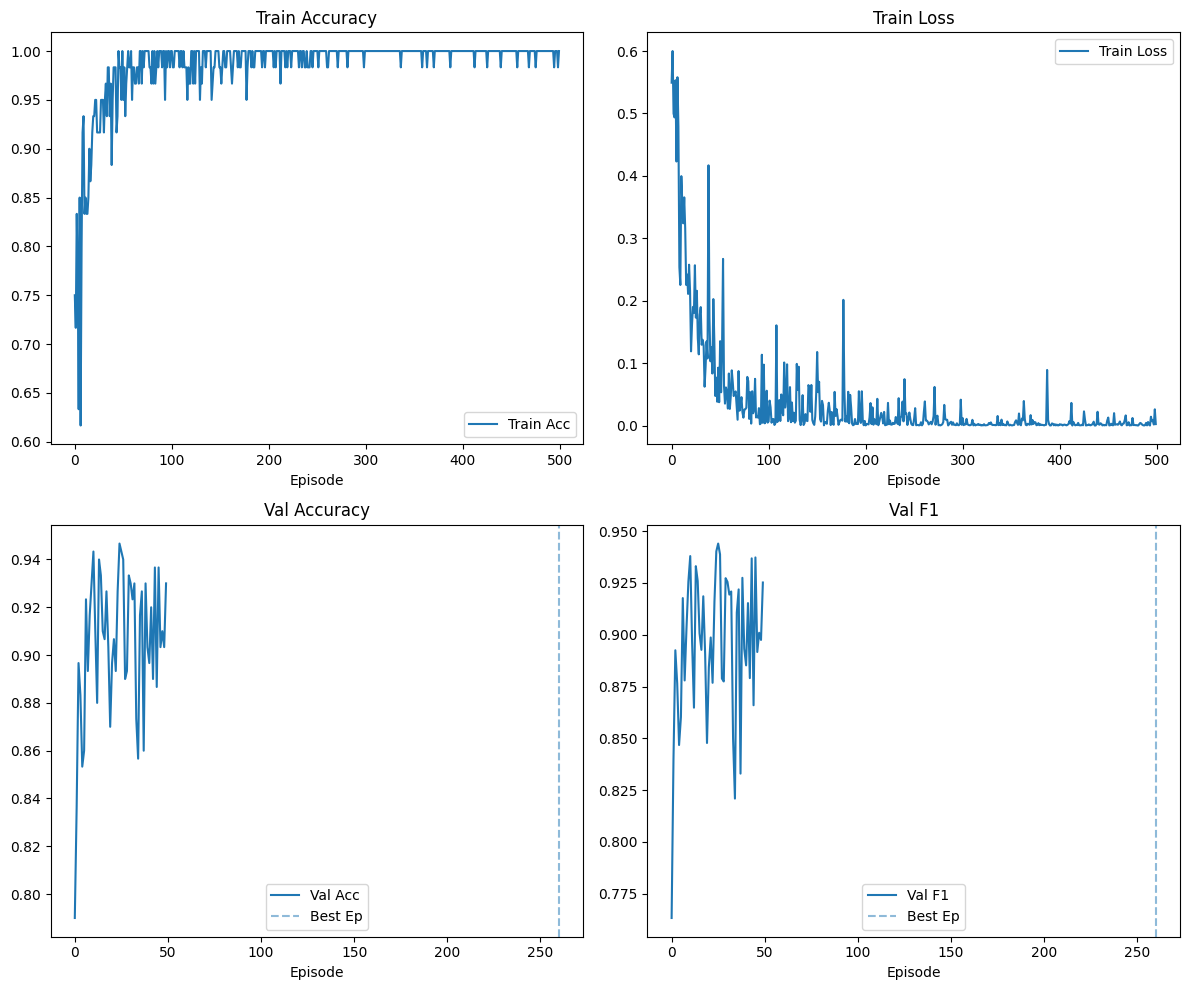

[TEST] Acc=0.8854 | Prec=0.9302 | Rec=0.8333 | F1=0.8791 | AUC=0.9774


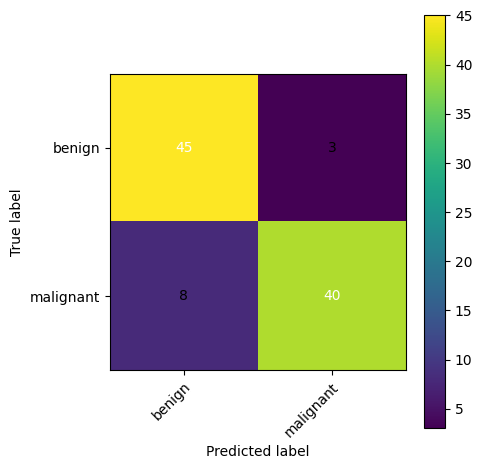

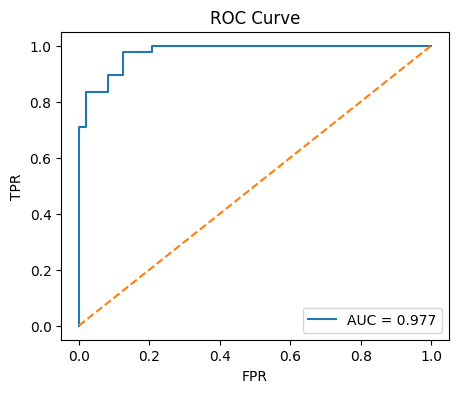

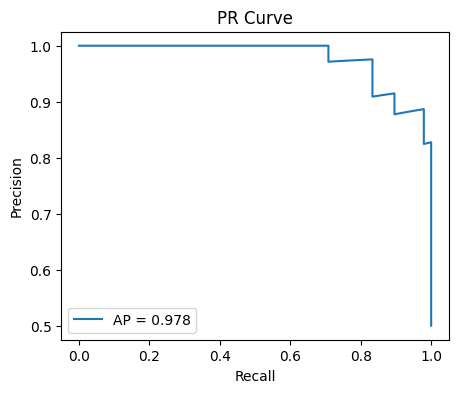

[DONE] Artifacts saved to: ./runs_protonet_20250824_232143


In [7]:
# ==========================================================
# protonet_fewshot.py (PyTorch 2.7.1 + cu118, Win compatible)
# ProtoNet (ResNet34) phân loại u gan (benign vs malignant)
# - Seed cố định, AMP, EarlyStopping, Validate theo chu kỳ
# - Lưu best model, Đánh giá cuối (CM + ROC/PR)
# - Dataset = 2 thư mục riêng (benign_fn_pc, malignant_fn_pc)
# ==========================================================
import os, time, json, random
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
)

# --------------------------
# 0) CẤU HÌNH
# --------------------------
OUTPUT_BENIGN_DIR    = "../data/train/benign"
OUTPUT_MALIGNANT_DIR = "../data/train/malignant"

OUTDIR       = f"./runs_protonet_{time.strftime('%Y%m%d_%H%M%S')}"
os.makedirs(OUTDIR, exist_ok=True)

# Few-shot Episodic setup
K_SHOT       = 30        # support mỗi lớp
N_QUERY      = 60        # tổng query/episode (chia đôi cho 2 lớp)
NUM_EPISODES = 500
VAL_EVERY    = 10
VAL_EPISODES = 5
SEED         = 42

# Huấn luyện
LR           = 5e-5
WEIGHT_DECAY = 1e-4
PATIENCE     = 40        # EarlyStopping theo Val F1
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_EMB    = 64
NUM_WORKERS  = 0 if os.name == "nt" else 2  # an toàn cho Windows

# --------------------------
# 1) HÀM TIỆN ÍCH
# --------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # tái lập kết quả
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

class EarlyStopping:
    def __init__(self, mode="max", patience=20, min_delta=1e-4):
        self.mode = mode
        self.patience = patience
        self.min_delta = min_delta
        self.best = -float("inf") if mode == "max" else float("inf")
        self.wait = 0
        self.should_stop = False

    def step(self, value):
        improved = (value > self.best + self.min_delta) if self.mode == "max" else (value < self.best - self.min_delta)
        if improved:
            self.best = value
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.should_stop = True
        return self.should_stop

def plot_training(history, best_ep, save_to=None):
    fig, axes = plt.subplots(2, 2, figsize=(12,10))
    axes = axes.ravel()

    axes[0].plot(history["train_acc"], label="Train Acc")
    axes[0].set_title("Train Accuracy"); axes[0].set_xlabel("Episode"); axes[0].legend()

    axes[1].plot(history["train_loss"], label="Train Loss")
    axes[1].set_title("Train Loss"); axes[1].set_xlabel("Episode"); axes[1].legend()

    axes[2].plot(history["val_acc"], label="Val Acc")
    if best_ep > 0: axes[2].axvline(best_ep, ls="--", alpha=.5, label="Best Ep")
    axes[2].set_title("Val Accuracy"); axes[2].set_xlabel("Episode"); axes[2].legend()

    axes[3].plot(history["val_f1"], label="Val F1")
    if best_ep > 0: axes[3].axvline(best_ep, ls="--", alpha=.5, label="Best Ep")
    axes[3].set_title("Val F1"); axes[3].set_xlabel("Episode"); axes[3].legend()

    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150)
    plt.show()

def plot_confusion_matrix(cm, class_names, save_to=None):
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names, yticklabels=class_names,
        ylabel='True label', xlabel='Predicted label'
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150)
    plt.show()

def plot_roc_pr(y_true, y_score, save_prefix=None):
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(rec, prec)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], ls="--")
    plt.title("ROC Curve"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
    if save_prefix: plt.savefig(f"{save_prefix}_roc.png", dpi=150)
    plt.show()

    plt.figure(figsize=(5,4))
    plt.plot(rec, prec, label=f"AP = {pr_auc:.3f}")
    plt.title("PR Curve"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
    if save_prefix: plt.savefig(f"{save_prefix}_pr.png", dpi=150)
    plt.show()

# --------------------------
# 2) DATASET & SPLIT
# --------------------------
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.1), ratio=(0.3,3.3)),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class LiverTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def list_images(folder):
    exts = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
    return [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(exts)]

if not os.path.isdir(OUTPUT_BENIGN_DIR) or not os.path.isdir(OUTPUT_MALIGNANT_DIR):
    raise RuntimeError("Kiểm tra lại đường dẫn OUTPUT_BENIGN_DIR / OUTPUT_MALIGNANT_DIR.")

benign_images    = list_images(OUTPUT_BENIGN_DIR)
malignant_images = list_images(OUTPUT_MALIGNANT_DIR)
if len(benign_images)==0 or len(malignant_images)==0:
    raise RuntimeError("Không tìm thấy ảnh trong một/both thư mục đầu vào.")

all_images = benign_images + malignant_images
all_labels = [0]*len(benign_images) + [1]*len(malignant_images)

idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    range(len(all_images)), all_labels, test_size=0.3, stratify=all_labels, random_state=SEED
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED
)

train_ds = LiverTumorDataset([all_images[i] for i in idx_train], [all_labels[i] for i in idx_train], transform=train_tf)
val_ds   = LiverTumorDataset([all_images[i] for i in idx_val],   [all_labels[i] for i in idx_val],   transform=eval_tf)
test_ds  = LiverTumorDataset([all_images[i] for i in idx_test],  [all_labels[i] for i in idx_test],  transform=eval_tf)

print(f"Train/Val/Test sizes: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")

# --------------------------
# 3) MÔ HÌNH PROTONET (RESNET34)
# --------------------------
class ProtoNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        m = models.resnet34(weights=models.ResNet34_Weights.DEFAULT if pretrained else None)
        m.fc = nn.Identity()
        self.backbone = m
    def forward(self, x):
        return self.backbone(x)  # (B, 512)

def prototypical_logits(query_emb, prototypes):
    # logits = - khoảng cách Euclidean tới prototype mỗi lớp
    dists = torch.cdist(query_emb, prototypes)
    return -dists

@torch.no_grad()
def compute_embeddings(model, dataset, batch=BATCH_EMB):
    dl = DataLoader(dataset, batch_size=batch, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
    model.eval()
    embs, labels = [], []
    for img, lab in dl:
        img = img.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE=="cuda")):
            e = model(img)
        embs.append(e.float().cpu())
        labels.append(lab)
    return torch.cat(embs, 0), torch.cat(labels, 0)

# --------------------------
# 4) EPISODE SAMPLING & TRAIN STEP
# --------------------------
def sample_episode(ds, k_shot=K_SHOT, n_query=N_QUERY):
    idx0 = [i for i,l in enumerate(ds.labels) if l==0]
    idx1 = [i for i,l in enumerate(ds.labels) if l==1]

    # Support (bù replace nếu thiếu)
    support0 = np.random.choice(idx0, size=k_shot, replace=len(idx0)<k_shot)
    support1 = np.random.choice(idx1, size=k_shot, replace=len(idx1)<k_shot)

    # Query (ưu tiên lấy phần còn lại, nếu thiếu => replace)
    remain0 = list(set(idx0) - set(support0))
    remain1 = list(set(idx1) - set(support1))
    query0  = np.random.choice(remain0 if len(remain0)>0 else idx0, size=n_query//2, replace=True)
    query1  = np.random.choice(remain1 if len(remain1)>0 else idx1, size=n_query//2, replace=True)

    def gather(indices):
        imgs, labs = [], []
        for i in indices:
            img, lab = ds[i]
            imgs.append(img.unsqueeze(0))
            labs.append(lab)
        return torch.cat(imgs, 0), torch.tensor(labs, dtype=torch.long)
    Xs, ys = gather(list(support0)+list(support1))
    Xq, yq = gather(list(query0)+list(query1))
    return Xs, ys, Xq, yq

def episode_step(model, optimizer, scaler, criterion, ds, train=True):
    Xs, ys, Xq, yq = sample_episode(ds, K_SHOT, N_QUERY)

    # đưa lên device (SỬA lỗi lệch device ở ys)
    Xs = Xs.to(DEVICE, non_blocking=True)
    Xq = Xq.to(DEVICE, non_blocking=True)
    ys = ys.to(DEVICE, non_blocking=True)
    yq = yq.to(DEVICE, non_blocking=True)

    model.train(mode=train)
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE=="cuda")):
        es = model(Xs)
        eq = model(Xq)

        # classes = [0,1] trên đúng device
        classes = torch.tensor([0, 1], device=DEVICE)
        protos = torch.stack([es[ys == c].mean(0) for c in classes], dim=0)  # (2, 512)

        logits = prototypical_logits(eq, protos)  # (Q, 2)
        loss = criterion(logits, yq)             # nhãn {0,1}

    if train:
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    # ---- metrics (SỬA lỗi y_pred bị scalar: dùng argmax trên ma trận 2 cột)
    with torch.no_grad():
        probs2d = F.softmax(logits.float(), dim=1)     # (Q, 2)
        y_prob  = probs2d[:, 1].detach().cpu().numpy() # (Q,) - nếu cần dùng
        y_pred  = probs2d.argmax(dim=1).detach().cpu().numpy()  # (Q,)
        y_true  = yq.detach().cpu().numpy()

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

    return loss.item(), acc, prec, rec, f1

# --------------------------
# 5) HUẤN LUYỆN
# --------------------------
model = ProtoNet(pretrained=True).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# PyTorch 2.7.1 KHÔNG có 'verbose' ở ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
criterion  = nn.CrossEntropyLoss()

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))
early  = EarlyStopping(mode="max", patience=PATIENCE, min_delta=1e-4)

history = {"train_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}
best_val_f1 = -1.0
best_ep     = -1
best_path   = os.path.join(OUTDIR, "best_protonet.pt")

print(f"[INFO] Training on {DEVICE} ...")
for ep in range(1, NUM_EPISODES+1):
    loss, tr_acc, tr_prec, tr_rec, tr_f1 = episode_step(model, optimizer, scaler, criterion, train_ds, train=True)
    history["train_loss"].append(loss)
    history["train_acc"].append(tr_acc)

    if ep % VAL_EVERY == 0:
        val_accs, val_f1s = [], []
        model.eval()
        with torch.no_grad():
            for _ in range(VAL_EPISODES):
                _, vacc, _, _, vf1 = episode_step(model, optimizer, scaler, criterion, val_ds, train=False)
                val_accs.append(vacc); val_f1s.append(vf1)
        mean_vacc = float(np.mean(val_accs))
        mean_vf1  = float(np.mean(val_f1s))
        history["val_acc"].append(mean_vacc)
        history["val_f1"].append(mean_vf1)

        # checkpoint theo Val F1
        if mean_vf1 > best_val_f1:
            best_val_f1 = mean_vf1
            best_ep     = ep
            torch.save({"model": model.state_dict(), "ep": ep}, best_path)

        # scheduler + early stop
        prev_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(mean_vf1)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr != prev_lr:
            print(f"[LR] ReduceLROnPlateau: lr {prev_lr:.2e} -> {new_lr:.2e}")

        if early.step(mean_vf1):
            print(f"[EarlyStop] Stop at episode {ep}. Best Val F1 = {best_val_f1:.4f} @ep {best_ep}")
            break

    if ep % 20 == 0 or ep == 1:
        msg = f"Ep {ep:4d}/{NUM_EPISODES} | loss {loss:.4f} | tr_acc {tr_acc:.3f} | tr_f1 {tr_f1:.3f}"
        if len(history['val_f1'])>0:
            msg += f" | val_acc {history['val_acc'][-1]:.3f} | val_f1 {history['val_f1'][-1]:.3f}"
        print(msg)

print(f"[INFO] Best Val F1 = {best_val_f1:.4f} @ episode {best_ep}")
plot_training(history, best_ep, save_to=os.path.join(OUTDIR, "train_curves.png"))

# --------------------------
# 6) ĐÁNH GIÁ CUỐI (PHI-EPISODIC)
# --------------------------
# nạp best model (SỬA: chỉ dùng map_location)
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

with torch.no_grad():
    emb_train, lab_train = compute_embeddings(model, train_ds, batch=BATCH_EMB)  # (Ntr, 512), (Ntr,)
    classes = torch.tensor([0,1])
    protos = torch.stack([emb_train[lab_train==c].mean(0) for c in classes], dim=0).to(DEVICE)  # (2, 512)

y_true_all, y_prob_all, y_pred_all = [], [], []
dl_test = DataLoader(test_ds, batch_size=BATCH_EMB, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
with torch.no_grad():
    for imgs, labs in dl_test:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(DEVICE=="cuda")):
            e = model(imgs).float()
        logits = prototypical_logits(e.to(DEVICE), protos)   # (B,2)
        probs2d = F.softmax(logits.float(), dim=1)
        y_prob  = probs2d[:, 1].cpu().numpy()
        y_hat   = probs2d.argmax(dim=1).cpu().numpy()

        y_true_all.append(labs.numpy())
        y_prob_all.append(y_prob)
        y_pred_all.append(y_hat)

y_true = np.concatenate(y_true_all)
y_prob = np.concatenate(y_prob_all)
y_pred = np.concatenate(y_pred_all)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
try:
    auc_roc = roc_auc_score(y_true, y_prob)
except Exception:
    auc_roc = float("nan")

print(f"[TEST] Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc_roc:.4f}")

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, ["benign", "malignant"], save_to=os.path.join(OUTDIR, "cm.png"))
plot_roc_pr(y_true, y_prob, save_prefix=os.path.join(OUTDIR, "curves"))

summary = {
    "best_val_f1": float(best_val_f1),
    "best_episode": int(best_ep),
    "test": {"acc": float(acc), "prec": float(prec), "rec": float(rec), "f1": float(f1), "auc": float(auc_roc)},
    "config": {
        "K_SHOT": K_SHOT, "N_QUERY": N_QUERY,
        "NUM_EPISODES": NUM_EPISODES, "VAL_EVERY": VAL_EVERY, "VAL_EPISODES": VAL_EPISODES,
        "LR": LR, "WEIGHT_DECAY": WEIGHT_DECAY, "PATIENCE": PATIENCE, "SEED": SEED
    },
    "classes": {0: "benign", 1: "malignant"}
}
with open(os.path.join(OUTDIR, "summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("[DONE] Artifacts saved to:", OUTDIR)
